# Macro-Conditional Normalizing Flow for Portfolio Risk Management


### Problem

Traditional risk models (Historical Simulation, parametric VaR) assume that asset return distributions are static and independent of the macroeconomic environment. In practice, correlations spike in crises, volatility clusters, and tail risks are heavily regime-dependent. This leads to systematic VaR underestimation precisely when it matters most.

**Our problem:** Can we build a more accurate portfolio risk model by conditioning the return distribution on the current macroeconomic regime?

### ML Formulation

We frame this as a **conditional density estimation** problem. Given the macroeconomic history of the past 63 trading days $M_{<t}$, we learn:

$$p(X_t \mid M_{<t;\,\theta}) \quad \text{where } X_t = (\text{SPY}_t,\, \text{TLT}_t,\, \text{GLD}_t) \in \mathbb{R}^3$$

The model is trained by minimizing the **Negative Log-Likelihood**:

$$\mathcal{L}(\theta) = -\frac{1}{T} \sum_{t=1}^{T} \log p_\theta(X_t \mid M_{<t})$$

This goes beyond price prediction, instead of predicting a single return, the model learns the **entire joint distribution**, capturing fat tails, volatility clustering, and time-varying correlations. The learned distribution is used to compute daily **99% VaR** and **Expected Shortfall**, validated out-of-sample via Kupiec's POF test (2022–2024 bear market).



### Architecture

$$[M_{<t}] \xrightarrow{\text{TFT}} h_t \xrightarrow{\text{MAF}} p(X_t \mid h_t)$$

### Key Design Choices

- **No look-ahead bias:** macro data aligned on publication dates via `pd.merge_asof()`, ensuring only publicly available information is used at each trading day.
- **No data leakage:** `StandardScaler` fitted exclusively on training data, then applied to validation and test sets.
- **Stationarity:** log returns instead of prices, YoY CPI, monthly NFP changes, first-differenced rates.
- **Heavy-tail modeling:** Normalizing Flow with a fat-tailed base distribution to capture extreme market events.
- **Formal validation:** Kupiec's POF test on out-of-sample VaR (2022-2024 bear market).

## 0. Setup & Imports

In [2]:
import os
import sys
import logging
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch

# Add project root to path
PROJECT_ROOT = os.path.dirname(os.path.abspath('.'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(name)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S',
)
logger = logging.getLogger('main')

# Matplotlib style
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

# ── FRED API KEY (required for macro data) ────────────────────────────────────
# Get a free key at: https://fred.stlouisfed.org/docs/api/api_key.html
# Then either:
#   a) Set env variable: set FRED_API_KEY=your_key_here (Windows)
#   b) Paste the key directly below
from dotenv import load_dotenv
load_dotenv()  # Load variables from .env file

FRED_API_KEY = os.environ.get('FRED_API_KEY', 'YOUR_FRED_API_KEY_HERE')
if FRED_API_KEY == 'YOUR_FRED_API_KEY_HERE':
    print('⚠️  WARNING: Please set your FRED API key!')
else:
    print('✓  FRED API key loaded.')

Using device: cpu
PyTorch version: 2.11.0
✓  FRED API key loaded.


## 1. Data Pipeline

### 1.1 Point-in-Time Data Alignment

The critical engineering challenge: macroeconomic data is released with a **delay** after the reference date.

Example: US CPI for **March 31st** is published on **~April 12th**.
If we naively join on 'observation_date', our model would 'know' March CPI on April 1st — **11 days early**.

**Solution**: `pd.merge_asof(..., direction='backward')` on `realtime_start` (publication date).

In [3]:
from src.data.pipeline import build_pipeline, SEQ_LEN, TICKERS

print('Building Point-in-Time dataset...')
print('This may take 2-3 minutes on first run (downloading data).')
print()

(
    train_loader,
    val_loader,
    test_loader,
    macro_scaler,
    ret_scaler,
    info,
    NUM_MACRO_FEATURES,
    NUM_ASSETS,
) = build_pipeline(fred_api_key=FRED_API_KEY, device=DEVICE)

print(f'\n✓ Pipeline built successfully!')
print(f'  Macro features: {NUM_MACRO_FEATURES}')
print(f'  Assets (D): {NUM_ASSETS} ({info["tickers"]})')
print(f'  Sequence length: {SEQ_LEN} days')
print(f'  Train samples: {info["train_shape"][0]:,}')
print(f'  Val samples:   {info["val_shape"][0]:,}')
print(f'  Test samples:  {info["test_shape"][0]:,}')
print(f'\nFeature columns ({NUM_MACRO_FEATURES} total):')
for i, col in enumerate(info['feature_cols']):
    print(f'  {i+1:2d}. {col}')

13:39:50 | src.data.pipeline | INFO | Building master point-in-time dataset...
13:39:50 | src.data.market_data | INFO | Downloading market data for ['SPY', 'TLT', 'GLD'] from 2004-01-01 to 2024-01-01


Building Point-in-Time dataset...
This may take 2-3 minutes on first run (downloading data).



13:39:52 | src.data.market_data | INFO | Market data downloaded. Shape: (5032, 3). Date range: 2004-01-05 to 2023-12-29
13:39:52 | src.data.macro_data | INFO | Downloading FRED series CPIAUCSL (CPI) with vintage dates...
13:39:54 | src.data.macro_data | INFO |   240 observations for CPIAUCSL. Publication range: 2004-02-20 to 2024-01-11
13:39:54 | src.data.macro_data | INFO | Downloading FRED series PAYEMS (NFP) with vintage dates...
13:39:56 | src.data.macro_data | INFO |   240 observations for PAYEMS. Publication range: 2004-02-06 to 2024-01-05
13:39:56 | src.data.macro_data | INFO | Downloading FRED series DFF (FedFundsRate) with vintage dates...
13:39:57 | src.data.macro_data | WARNING | Could not download vintage data for DFF: Bad Request.  There are 5003 vintage dates in the specified real-time period: 1776-07-04 to 9999-12-31.  This exceeds the maximum number of vintage dates allowed for this file type (2000).. Falling back to basic download.
13:39:59 | src.data.macro_data | INFO


✓ Pipeline built successfully!
  Macro features: 8
  Assets (D): 3 (['SPY', 'TLT', 'GLD'])
  Sequence length: 63 days
  Train samples: 2,923
  Val samples:   1,196
  Test samples:  438

Feature columns (8 total):
   1. CPI
   2. NFP
   3. FedFundsRate
   4. HYSpread
   5. VIX
   6. SPY_RealVol21d
   7. TLT_RealVol21d
   8. GLD_RealVol21d


### 1.2 Exploratory Data Analysis

13:40:03 | src.data.market_data | INFO | Downloading market data for ['SPY', 'TLT', 'GLD'] from 2004-01-01 to 2024-01-01
13:40:03 | src.data.market_data | INFO | Market data downloaded. Shape: (5032, 3). Date range: 2004-01-05 to 2023-12-29


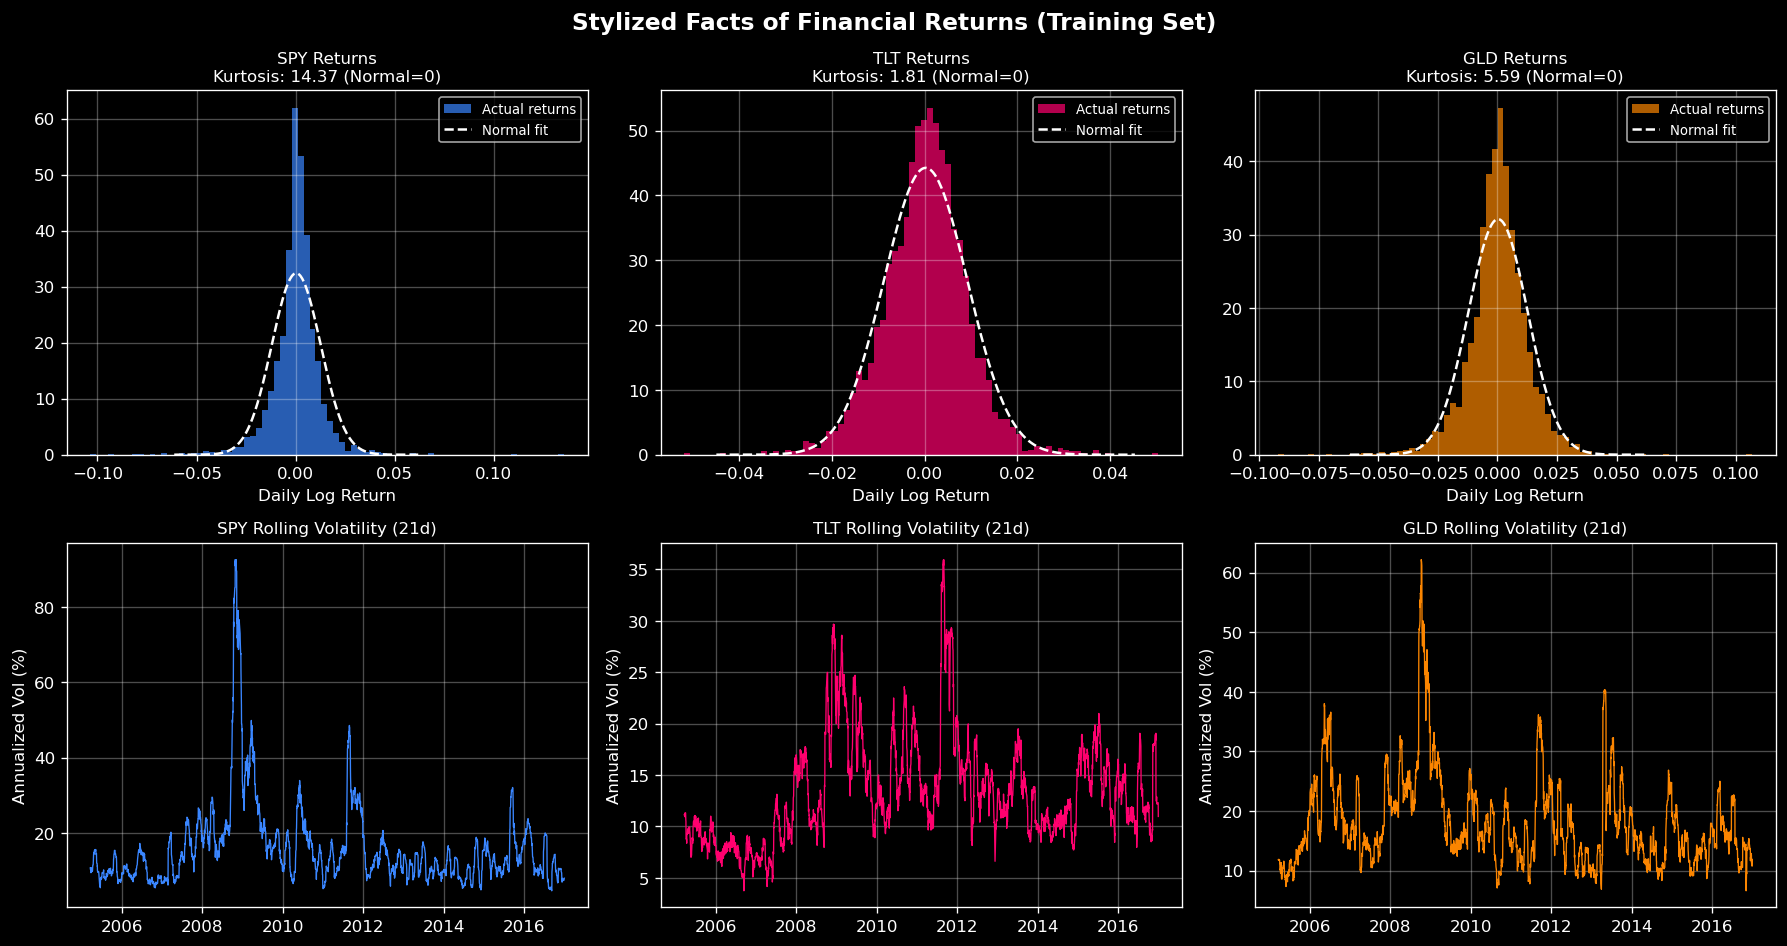

Figure 1: Stylized facts — note heavy tails (kurtosis > 0) and volatility clustering.


In [4]:
from src.data.market_data import download_market_data
from scipy import stats

returns_df = download_market_data(tickers=TICKERS)
master_train = info['master_train']
ret_cols = info['ret_cols']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Stylized Facts of Financial Returns (Training Set)', fontsize=14, fontweight='bold')

colors = ['#3a86ff', '#ff006e', '#fb8500']

# Row 1: Return distributions vs Normal
for i, (col, ticker, color) in enumerate(zip(ret_cols, TICKERS, colors)):
    ax = axes[0, i]
    data = master_train[col].dropna()
    ax.hist(data, bins=80, density=True, color=color, alpha=0.7, label='Actual returns')
    
    # Overlay normal distribution
    mu, sigma = data.mean(), data.std()
    x_range = np.linspace(mu - 5*sigma, mu + 5*sigma, 300)
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'w--', linewidth=1.5, label='Normal fit')
    
    kurt = stats.kurtosis(data)
    ax.set_title(f'{ticker} Returns\nKurtosis: {kurt:.2f} (Normal=0)', fontsize=10)
    ax.set_xlabel('Daily Log Return')
    ax.legend(fontsize=8)

# Row 2: Volatility clustering (rolling std)
for i, (col, ticker, color) in enumerate(zip(ret_cols, TICKERS, colors)):
    ax = axes[1, i]
    data = master_train[col].dropna()
    rolling_vol = data.rolling(21).std() * np.sqrt(252)  # Annualized
    ax.plot(rolling_vol.index, rolling_vol * 100, color=color, linewidth=0.8)
    ax.set_title(f'{ticker} Rolling Volatility (21d)', fontsize=10)
    ax.set_ylabel('Annualized Vol (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_stylized_facts.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure 1: Stylized facts — note heavy tails (kurtosis > 0) and volatility clustering.')

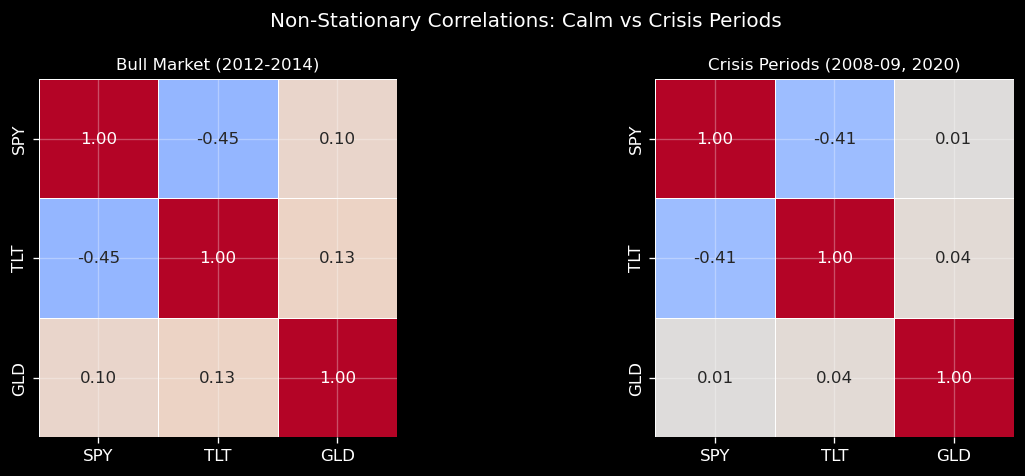

Figure 2: Correlations shift dramatically between calm and crisis — justifying macro conditioning.


In [5]:
# Correlation structure in normal vs stress periods
train_returns = master_train[ret_cols].dropna()

# Define stress period: 2008 Financial Crisis + 2020 COVID
stress = train_returns[
    (train_returns.index.year.isin([2008, 2009])) |
    (train_returns.index.year == 2020)
]
calm = train_returns[
    train_returns.index.year.isin([2012, 2013, 2014])
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Non-Stationary Correlations: Calm vs Crisis Periods', fontsize=12)

kw = dict(annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
          square=True, linewidths=0.5, cbar=False)

ticker_labels = TICKERS

sns.heatmap(calm.rename(columns=dict(zip(ret_cols, ticker_labels))).corr(),
            ax=axes[0], **kw)
axes[0].set_title('Bull Market (2012-2014)', fontsize=10)

sns.heatmap(stress.rename(columns=dict(zip(ret_cols, ticker_labels))).corr(),
            ax=axes[1], **kw)
axes[1].set_title('Crisis Periods (2008-09, 2020)', fontsize=10)

plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure 2: Correlations shift dramatically between calm and crisis — justifying macro conditioning.')

## 2. Model Architecture

### 2.1 Instantiate the Conditional Normalizing Flow

In [6]:
from src.models.flow_model import ConditionalNormalizingFlow

model = ConditionalNormalizingFlow(
    num_macro_features=NUM_MACRO_FEATURES,
    num_assets=NUM_ASSETS,
    # TFT encoder settings
    tft_d_model=128,
    tft_n_heads=4,
    tft_n_lstm_layers=2,
    # MAF decoder settings
    flow_n_layers=8,
    flow_hidden_dim=128,
    flow_n_hidden=3,
    dropout=0.1,
).to(DEVICE)

param_counts = model.count_parameters()
print(f'Model Architecture:')
print(f'  TFT Encoder: {param_counts["tft"]:,} parameters')
print(f'  MAF Decoder: {param_counts["flow"]:,} parameters')
print(f'  Total:       {param_counts["total"]:,} parameters')

# Sanity check: forward pass
batch = next(iter(train_loader))
macro_batch, ret_batch = batch[0].to(DEVICE), batch[1].to(DEVICE)
nll_test, weights_test = model(ret_batch, macro_batch)
print(f'\nSanity check forward pass:')
print(f'  Input shapes: macro={macro_batch.shape}, returns={ret_batch.shape}')
print(f'  Initial NLL: {nll_test.item():.4f} (should be roughly D/2*log(2π) ≈ {NUM_ASSETS/2*np.log(2*np.pi):.2f})')
print(f'  Variable weights shape: {weights_test.shape}')

Model Architecture:
  TFT Encoder: 1,169,576 parameters
  MAF Decoder: 537,690 parameters
  Total:       1,707,266 parameters

Sanity check forward pass:
  Input shapes: macro=torch.Size([64, 63, 8]), returns=torch.Size([64, 3])
  Initial NLL: 4.2740 (should be roughly D/2*log(2π) ≈ 2.76)
  Variable weights shape: torch.Size([64, 63, 8])


## 3. Training

We minimize the **Negative Log-Likelihood (NLL)**:

$$\mathcal{L}(\theta) = -\mathbb{E}\left[\log p_Z(g_\theta(x; h_t)) + \log\left|\det\frac{\partial g_\theta}{\partial x}\right|\right]$$

The log-determinant term is **O(D)** due to the triangular Jacobian from MADE masks.

In [7]:
import os
from src.training.trainer import Trainer

os.makedirs('checkpoints', exist_ok=True)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=2e-4,
    weight_decay=1e-5,
    n_epochs=1, # I PUT 1 HERE JUST TO RUN ALL CELLS FASTER, CHANGE BACK TO 60
    patience=12,
    grad_clip=0.5,
    checkpoint_path='checkpoints/best_model.pt',
    device=DEVICE,
    warmup_epochs=2,
)

print('Starting training...')
print('(Training on CPU may take 20-60 min; on GPU ~5-10 min. Reduce n_epochs if needed.)')
history = trainer.fit()

13:40:04 | src.training.trainer | INFO | Training on device: cpu
13:40:04 | src.training.trainer | INFO | Model parameters: TFT=1169576, Flow=537690, Total=1707266
13:40:05 | src.training.trainer | INFO | Starting training for up to 1 epochs...


Starting training...
(Training on CPU may take 20-60 min; on GPU ~5-10 min. Reduce n_epochs if needed.)


13:40:19 | src.training.trainer | INFO | Epoch   1/1 | Train NLL: 4.0067 | Val NLL: 3.5576 | LR: 1.00e-04
13:40:20 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 3.5576)
13:40:20 | src.training.trainer | INFO | Training complete. Best model at epoch 1 with val NLL: 3.5576


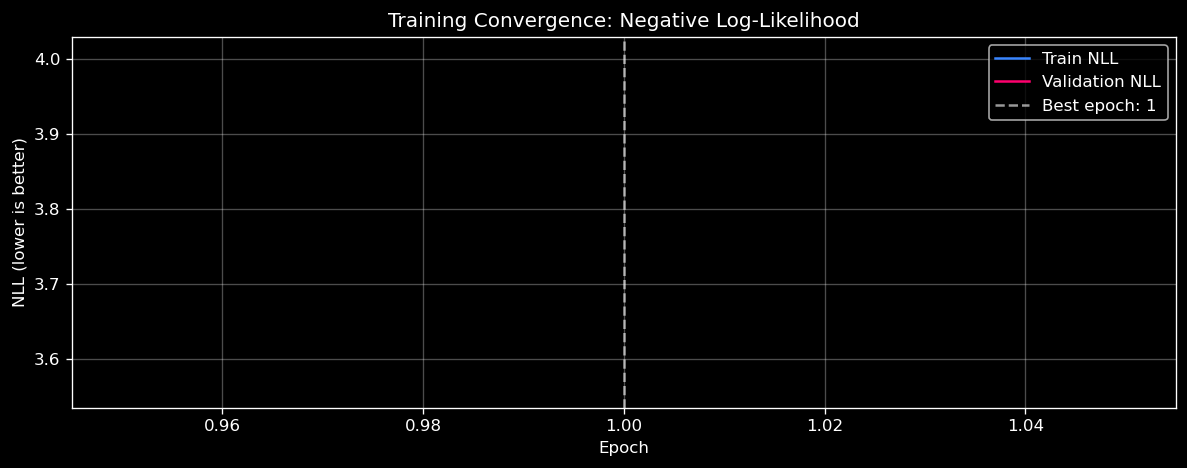

Best epoch: 1, Best val NLL: 3.5576


In [8]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 4))

epochs = range(1, len(history['train_nll']) + 1)
ax.plot(epochs, history['train_nll'], '#3a86ff', linewidth=1.5, label='Train NLL')
ax.plot(epochs, history['val_nll'],   '#ff006e', linewidth=1.5, label='Validation NLL')

best_epoch = int(np.argmin(history['val_nll'])) + 1
ax.axvline(best_epoch, color='white', linestyle='--', alpha=0.6,
           label=f'Best epoch: {best_epoch}')

ax.set_xlabel('Epoch')
ax.set_ylabel('NLL (lower is better)')
ax.set_title('Training Convergence: Negative Log-Likelihood')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Best epoch: {best_epoch}, Best val NLL: {min(history["val_nll"]):.4f}')

In [9]:
# Load best model
trainer.load_best_model()
print('Best model loaded.')

13:40:20 | src.training.trainer | INFO | Loaded best model from epoch 1 (val NLL: 3.5576)


Best model loaded.


## 4. Financial Backtesting

### 4.1 Monte Carlo VaR & Expected Shortfall

For each test day $t$:
1. Pass macro sequence $M_{<t}$ through TFT → $h_t$
2. Draw 10,000 samples from $p(X_t | h_t)$
3. Compute empirical **99% VaR** and **Expected Shortfall** from those samples
4. Compare against actual portfolio return

> **Test period**: 2022–2023 (US equity bear market + rate hiking cycle)

In [10]:
from src.backtest.backtester import Backtester

backtester = Backtester(
    model=model,
    test_loader=test_loader,
    test_dates=info['dates_test'],
    ret_scaler=ret_scaler,
    tickers=TICKERS,
    n_mc_samples=10_000,
    alpha=0.01,    # 99% VaR
    device=DEVICE,
)

print('Running out-of-sample backtest (drawing 10k MC samples per day)...')
results = backtester.run()
print('\nBacktest complete!')

13:40:20 | src.backtest.backtester | INFO | Pre-computing context vectors h_t for all 438 test days...


Running out-of-sample backtest (drawing 10k MC samples per day)...


13:40:20 | src.backtest.backtester | INFO | Sampling 10000 MC draws per day for 438 days...
Backtesting: 100%|██████████| 438/438 [00:58<00:00,  7.48it/s]
13:41:19 | src.backtest.backtester | INFO | === Backtest Results ===
13:41:19 | src.backtest.backtester | INFO | Period: 2022-04-04 to 2023-12-29 (438 days)
13:41:19 | src.backtest.backtester | INFO | VaR breaches: 12 / 438 (2.74% observed vs 1.00% expected)
13:41:19 | src.backtest.backtester | INFO | Kupiec LR: 9.0833, p-value: 0.0026
13:41:19 | src.backtest.backtester | INFO | FAIL: Model UNDER-estimates tail risk. Observed 2.74% breaches vs expected 1.00%. VaR is too optimistic.



Backtest complete!


### 4.2 VaR Bands Plot

13:41:20 | src.backtest.backtester | INFO | VaR plot saved to backtest_var_bands.png


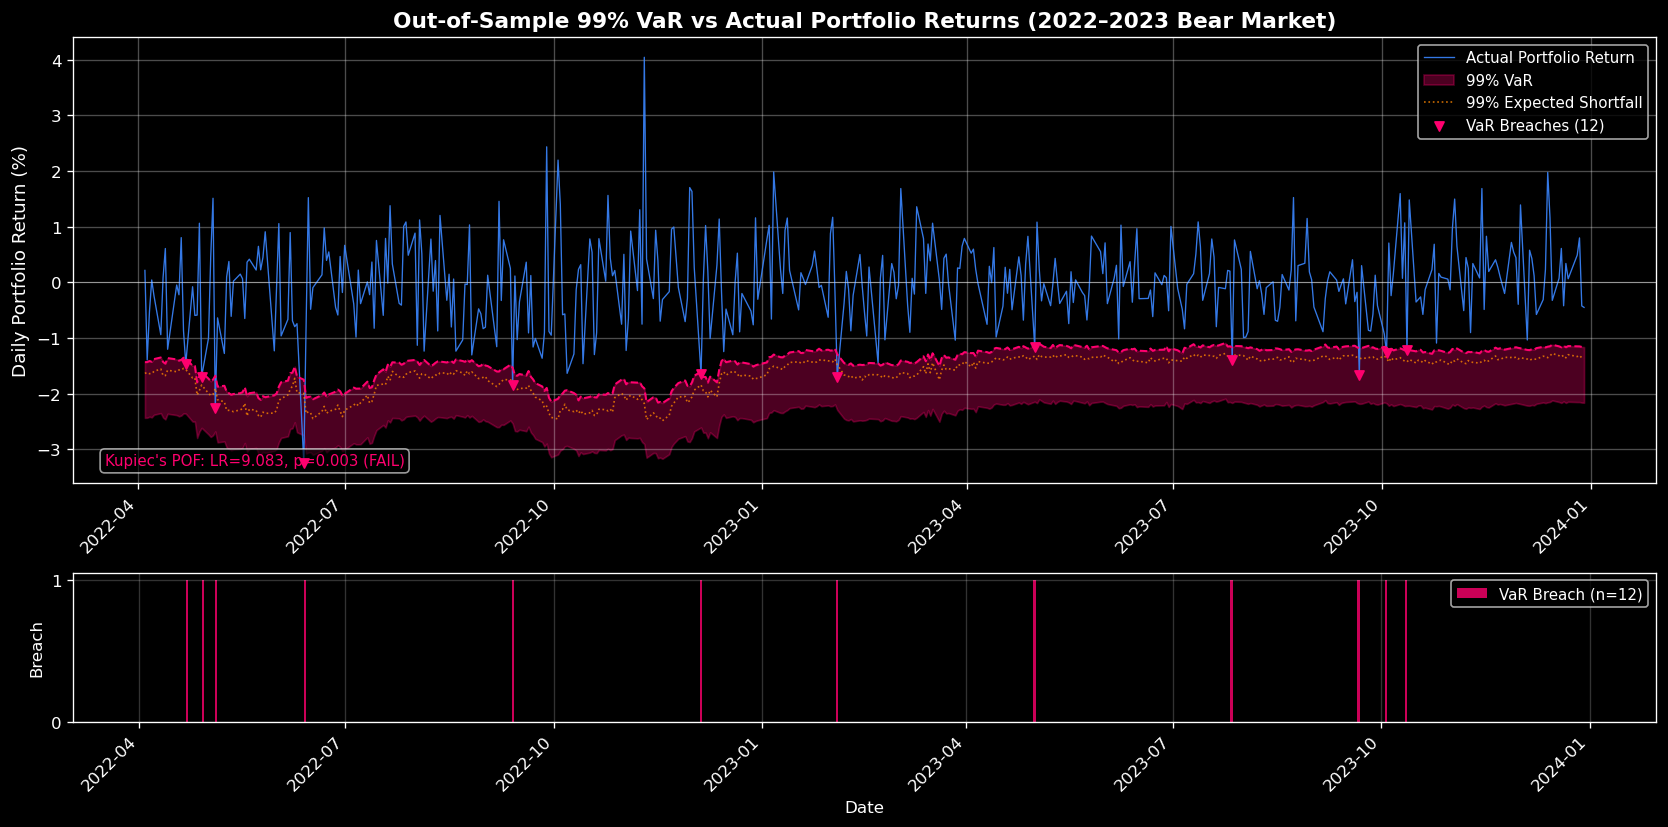

In [11]:
fig = backtester.plot_var_bands(
    output_path='backtest_var_bands.png',
    title='Out-of-Sample 99% VaR vs Actual Portfolio Returns (2022–2023 Bear Market)',
)
plt.show()

### 4.3 Kupiec's POF Test Results

In [12]:
from src.backtest.risk_metrics import kupiec_pof_test

# Full backtest summary
summary_df = backtester.summary()
print('='*55)
print('         BACKTEST SUMMARY REPORT')
print('='*55)
for _, row in summary_df.iterrows():
    print(f'{row["Metric"]:<35} {row["Value"]}')
print('='*55)

         BACKTEST SUMMARY REPORT
Backtest Period                     2022-04-04 to 2023-12-29
Total Days                          438
VaR Confidence Level                99%
Expected Breaches                   4.4
Observed Breaches                   12
Observed Breach Rate                2.74%
Kupiec LR Statistic                 9.0833
Kupiec p-value                      0.0026
Kupiec Result                       FAIL
Mean Daily VaR                      -1.449%
Mean Daily ES                       -1.667%
Mean Actual Daily Return            -0.008%
Worst Day (actual)                  -3.245%


KUPIEC PROPORTION OF FAILURES (POF) TEST
--------------------------------------------------
H0: True breach probability = 1% (model is correct)
H1: True breach probability ≠ 1% (model is mis-calibrated)

Observations:         438
Expected breaches:    4.4
Observed breaches:    12
Observed breach rate: 2.74%

LR Statistic:         9.0833
Chi-squared 5% CV:    3.841
p-value:              0.0026

VERDICT: FAIL: Model UNDER-estimates tail risk. Observed 2.74% breaches vs expected 1.00%. VaR is too optimistic.


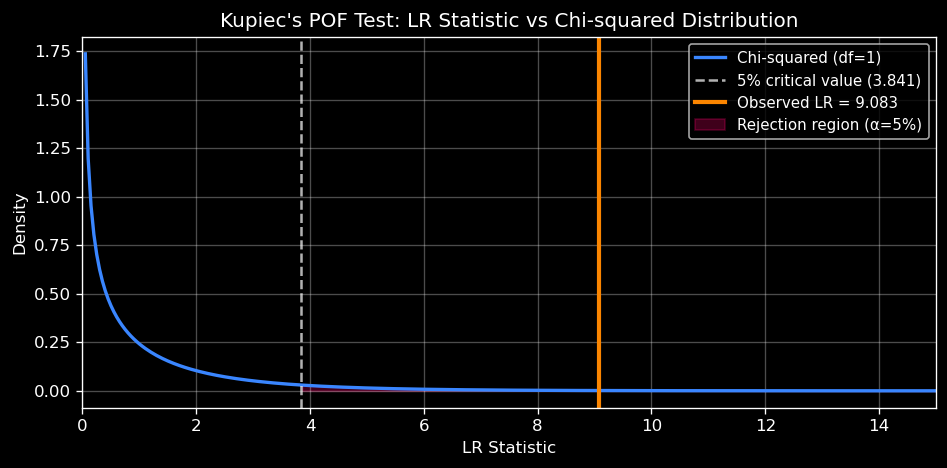

In [13]:
# Detailed Kupiec test interpretation
kupiec = backtester.kupiec_result

print(f'KUPIEC PROPORTION OF FAILURES (POF) TEST')
print(f'-' * 50)
print(f'H0: True breach probability = {kupiec.expected_rate:.0%} (model is correct)')
print(f'H1: True breach probability ≠ {kupiec.expected_rate:.0%} (model is mis-calibrated)')
print()
print(f'Observations:         {kupiec.n_obs}')
print(f'Expected breaches:    {kupiec.expected_breaches:.1f}')
print(f'Observed breaches:    {kupiec.n_breaches}')
print(f'Observed breach rate: {kupiec.breach_rate:.2%}')
print()
print(f'LR Statistic:         {kupiec.lr_statistic:.4f}')
print(f'Chi-squared 5% CV:    3.841')
print(f'p-value:              {kupiec.p_value:.4f}')
print()
print(f'VERDICT: {kupiec.interpretation}')

# Visualize the LR test
from scipy import stats as scipy_stats
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(0, 15, 300)
ax.plot(x, scipy_stats.chi2.pdf(x, df=1), '#3a86ff', linewidth=2, label='Chi-squared (df=1)')
ax.axvline(3.841, color='white', linestyle='--', alpha=0.7, label='5% critical value (3.841)')
ax.axvline(kupiec.lr_statistic, color='#fb8500', linestyle='-', linewidth=2.5,
           label=f'Observed LR = {kupiec.lr_statistic:.3f}')
ax.fill_between(x[x >= 3.841], scipy_stats.chi2.pdf(x[x >= 3.841], df=1),
                alpha=0.25, color='#ff006e', label='Rejection region (α=5%)')
ax.set_xlabel('LR Statistic')
ax.set_ylabel('Density')
ax.set_title("Kupiec's POF Test: LR Statistic vs Chi-squared Distribution")
ax.legend(fontsize=9)
ax.set_xlim(0, 15)
plt.tight_layout()
plt.savefig('kupiec_test.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Model Interpretability: Variable Importance (TFT)

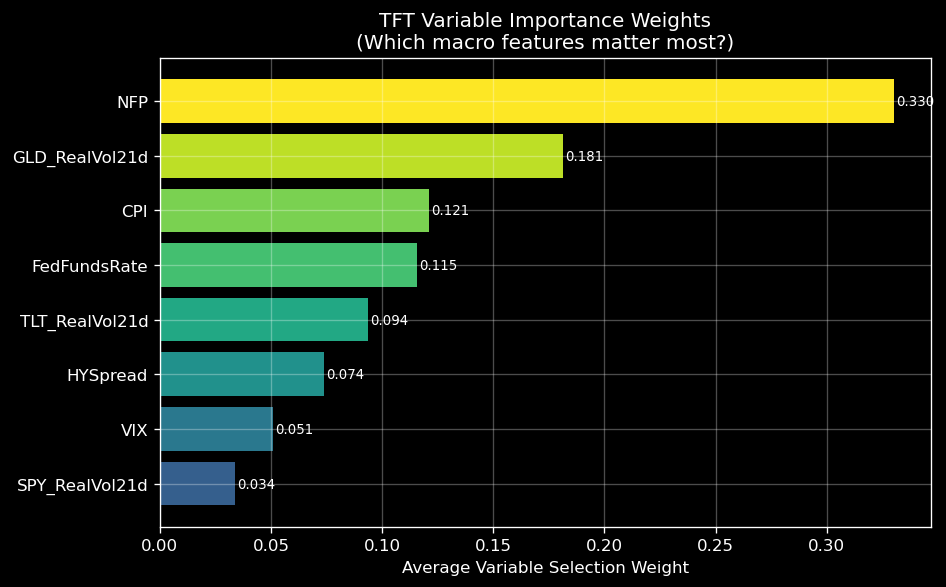

The TFT automatically learns which macro features drive the return distribution.


In [14]:
# Compute average variable importance across the test set
model.eval()
feature_names = info['feature_cols']

all_importances = []
with torch.no_grad():
    for macro_seq, _ in test_loader:
        macro_seq = macro_seq.to(DEVICE)
        importance = model.get_variable_importance(macro_seq)
        all_importances.append(importance.cpu().numpy())

avg_importance = np.array(all_importances).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': avg_importance,
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = plt.cm.viridis(np.linspace(0.3, 1.0, len(importance_df)))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=colors_bar, edgecolor='none')
ax.set_xlabel('Average Variable Selection Weight')
ax.set_title('TFT Variable Importance Weights\n(Which macro features matter most?)')
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('variable_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('The TFT automatically learns which macro features drive the return distribution.')

## 6. Summary

### Results

In [15]:
print('=' * 60)
print('     MACRO-CONDITIONAL NORMALIZING FLOW — SUMMARY')
print('=' * 60)
print()
print('ARCHITECTURE:')
print(f'  Macro Encoder : Temporal Fusion Transformer (TFT)')
print(f'                  {model.tft_d_model}d hidden, 4 attention heads, 2-layer LSTM')
print(f'  Flow Decoder  : Masked Autoregressive Flow (MAF)')
print(f'                  8 MADE layers, 128d hidden, O(D) Jacobian')
print(f'  Parameters    : {model.count_parameters()["total"]:,} total')
print()
print('DATA ENGINEERING:')
print(f'  Assets : SPY (Equity), TLT (Bonds), GLD (Gold)')
print(f'  Macro  : CPI (YoY%), NFP (diff), Fed Funds Rate (diff),')
print(f'           HY Spread, VIX + rolling realized vols')
print(f'  PIT Alignment: pd.merge_asof on publication date ← no look-ahead')
print(f'  Scaler: fitted on training set only ← no data leakage')
print()
print('BACKTEST (2022–2023):')
kupiec = backtester.kupiec_result
print(f'  VaR Level   : 99%')
print(f'  Breaches    : {kupiec.n_breaches} / {kupiec.n_obs} ({kupiec.breach_rate:.2%} observed vs {kupiec.expected_rate:.2%} expected)')
print(f'  Kupiec Test : LR={kupiec.lr_statistic:.3f}, p={kupiec.p_value:.3f} → {"PASS ✓" if not kupiec.reject_h0 else "FAIL ✗"}')
print()
print('Generated files:')
print('  eda_stylized_facts.png')
print('  eda_correlations.png')
print('  training_curves.png')
print('  backtest_var_bands.png')
print('  kupiec_test.png')
print('  variable_importance.png')
print('  checkpoints/best_model.pt')

     MACRO-CONDITIONAL NORMALIZING FLOW — SUMMARY

ARCHITECTURE:
  Macro Encoder : Temporal Fusion Transformer (TFT)
                  128d hidden, 4 attention heads, 2-layer LSTM
  Flow Decoder  : Masked Autoregressive Flow (MAF)
                  8 MADE layers, 128d hidden, O(D) Jacobian
  Parameters    : 1,707,266 total

DATA ENGINEERING:
  Assets : SPY (Equity), TLT (Bonds), GLD (Gold)
  Macro  : CPI (YoY%), NFP (diff), Fed Funds Rate (diff),
           HY Spread, VIX + rolling realized vols
  PIT Alignment: pd.merge_asof on publication date ← no look-ahead
  Scaler: fitted on training set only ← no data leakage

BACKTEST (2022–2023):
  VaR Level   : 99%
  Breaches    : 12 / 438 (2.74% observed vs 1.00% expected)
  Kupiec Test : LR=9.083, p=0.003 → FAIL ✗

Generated files:
  eda_stylized_facts.png
  eda_correlations.png
  training_curves.png
  backtest_var_bands.png
  kupiec_test.png
  variable_importance.png
  checkpoints/best_model.pt


## 7. Walk-Forward Cross-Validation

To rigorously evaluate the model's out-of-sample performance and avoid overfitting to a single static historical period, we use an **Expanding Window Walk-Forward** validation approach with **Warm Starts**.

### Why this approach?

1. **Expanding Window vs. Rolling Window**:
   - *Our Choice: Expanding Window*. The model is trained on an initial historical period (e.g., 2005-2016). It is evaluated on the subsequent year (2017), and then that year is permanently added to the training set. 
   - *Justification*: Normalizing flows are data-hungry. Deep learning models generally perform far better when provided with massive historical datasets. By using an expanding window instead of a fixed rolling window (where old data is dropped), our Temporal Fusion Transformer (TFT) can see multiple distinct market regimes (e.g., the 2008 crisis, calm 2010s) and develop a more robust generic understanding of market dynamics, rather than "forgetting" past crises.

2. **Warm Start vs. Cold Start**:
   - *Our Choice: Warm Start*. To significantly speed up training, the model's weights are preserved between folds. For each new fold, the optimizer is refreshed, and the model fine-tunes its existing knowledge using the newly added data.
   - *Justification*: Randomly re-initializing the model (Cold Start) for every fold provides statistically independent tests, but is extremely slow. Since this is an intensive architecture, fine-tuning allows us to run extensive walk-forward loops in a fraction of the time, making the experimentation process feasible under our computational constraints.

The code block below dynamically creates these expanding data folds, continuously trains the model with warm starts, and sequentially aggregates the true out-of-sample VaR and ES predictions to compute a global Kupiec POF test score.

13:41:21 | src.data.pipeline | INFO | Building master point-in-time dataset...
13:41:21 | src.data.market_data | INFO | Downloading market data for ['SPY', 'TLT', 'GLD'] from 2004-01-01 to 2024-01-01
13:41:21 | src.data.market_data | INFO | Market data downloaded. Shape: (5032, 3). Date range: 2004-01-05 to 2023-12-29
13:41:21 | src.data.macro_data | INFO | Downloading FRED series CPIAUCSL (CPI) with vintage dates...


Starting Walk-Forward Validation...


13:41:23 | src.data.macro_data | INFO |   240 observations for CPIAUCSL. Publication range: 2004-02-20 to 2024-01-11
13:41:23 | src.data.macro_data | INFO | Downloading FRED series PAYEMS (NFP) with vintage dates...
13:41:25 | src.data.macro_data | INFO |   240 observations for PAYEMS. Publication range: 2004-02-06 to 2024-01-05
13:41:25 | src.data.macro_data | INFO | Downloading FRED series DFF (FedFundsRate) with vintage dates...
13:41:26 | src.data.macro_data | WARNING | Could not download vintage data for DFF: Bad Request.  There are 5003 vintage dates in the specified real-time period: 1776-07-04 to 9999-12-31.  This exceeds the maximum number of vintage dates allowed for this file type (2000).. Falling back to basic download.
13:41:28 | src.data.macro_data | INFO | Downloading FRED series BAMLH0A0HYM2 (HYSpread) with vintage dates...
13:41:29 | src.data.macro_data | WARNING | Could not download vintage data for BAMLH0A0HYM2: Bad Request.  There are 3118 vintage dates in the speci

------------------------------------------------------------
Fold 1 | Train End: 2016-12-31 | Test: 2018-01-01 to 2018-12-31


13:41:38 | src.training.trainer | INFO | Epoch   1/20 | Train NLL: 3.9103 | Val NLL: 2.4454 | LR: 1.50e-04
13:41:38 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 2.4454)
13:41:44 | src.training.trainer | INFO | Epoch   2/20 | Train NLL: 3.7324 | Val NLL: 2.3061 | LR: 3.00e-04
13:41:44 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 2.3061)
13:41:51 | src.training.trainer | INFO | Epoch   3/20 | Train NLL: 3.6570 | Val NLL: 2.1980 | LR: 2.98e-04
13:41:51 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 2.1980)
13:41:58 | src.training.trainer | INFO | Epoch   4/20 | Train NLL: 3.5985 | Val NLL: 2.2517 | LR: 2.91e-04
13:42:04 | src.training.trainer | INFO | Epoch   5/20 | Train NLL: 3.5858 | Val NLL: 2.1668 | LR: 2.80e-04
13:42:04 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 2.1668)
13:42:11 | src.training.trainer | INFO | Epoch   6/20 | Train NLL: 3.5606 | Val NLL: 2.0998 | LR: 2.65e-04
13:42:11 | src.training.trainer | INFO

...

------------------------------------------------------------
Fold 5 | Train End: 2020-12-31 | Test: 2022-01-01 to 2022-12-31
Warm-starting model...


13:46:40 | src.training.trainer | INFO | Epoch   1/20 | Train NLL: 3.3478 | Val NLL: 3.3939 | LR: 1.50e-04
13:46:40 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 3.3939)
13:46:48 | src.training.trainer | INFO | Epoch   2/20 | Train NLL: 3.3529 | Val NLL: 3.5360 | LR: 3.00e-04
13:46:57 | src.training.trainer | INFO | Epoch   3/20 | Train NLL: 3.3440 | Val NLL: 3.3529 | LR: 2.98e-04
13:46:57 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 3.3529)
13:47:05 | src.training.trainer | INFO | Epoch   4/20 | Train NLL: 3.3320 | Val NLL: 3.4286 | LR: 2.91e-04
13:47:14 | src.training.trainer | INFO | Epoch   5/20 | Train NLL: 3.3266 | Val NLL: 3.4436 | LR: 2.80e-04
13:47:22 | src.training.trainer | INFO | Epoch   6/20 | Train NLL: 3.3020 | Val NLL: 3.4382 | LR: 2.65e-04
13:47:31 | src.training.trainer | INFO | Epoch   7/20 | Train NLL: 3.3033 | Val NLL: 3.4415 | LR: 2.47e-04
13:47:39 | src.training.trainer | INFO | Epoch   8/20 | Train NLL: 3.2943 | Val NLL: 3.4860

------------------------------------------------------------
Fold 6 | Train End: 2021-12-31 | Test: 2023-01-01 to 2023-12-31
Warm-starting model...


13:47:51 | src.training.trainer | INFO | Epoch   1/20 | Train NLL: 3.3728 | Val NLL: 5.5225 | LR: 1.50e-04
13:47:51 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 5.5225)
13:48:00 | src.training.trainer | INFO | Epoch   2/20 | Train NLL: 3.3558 | Val NLL: 5.5090 | LR: 3.00e-04
13:48:00 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 5.5090)
13:48:09 | src.training.trainer | INFO | Epoch   3/20 | Train NLL: 3.3614 | Val NLL: 5.5343 | LR: 2.98e-04
13:48:18 | src.training.trainer | INFO | Epoch   4/20 | Train NLL: 3.3543 | Val NLL: 5.2794 | LR: 2.91e-04
13:48:18 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 5.2794)
13:48:27 | src.training.trainer | INFO | Epoch   5/20 | Train NLL: 3.3310 | Val NLL: 5.4909 | LR: 2.80e-04
13:48:36 | src.training.trainer | INFO | Epoch   6/20 | Train NLL: 3.3271 | Val NLL: 5.4880 | LR: 2.65e-04
13:48:45 | src.training.trainer | INFO | Epoch   7/20 | Train NLL: 3.3046 | Val NLL: 5.6103 | LR: 2.47e-04
13:48:54 | 

------------------------------------------------------------
Walk-Forward Cross-Validation Complete in 7.76 minutes.
Aggregated OOS Period: 2018-04-04 to 2023-12-29
Total aggregate VaR breaches: 32 / 1131 (2.83%)
Global Kupiec LR Statistic: 25.5678, p-value: 0.0000


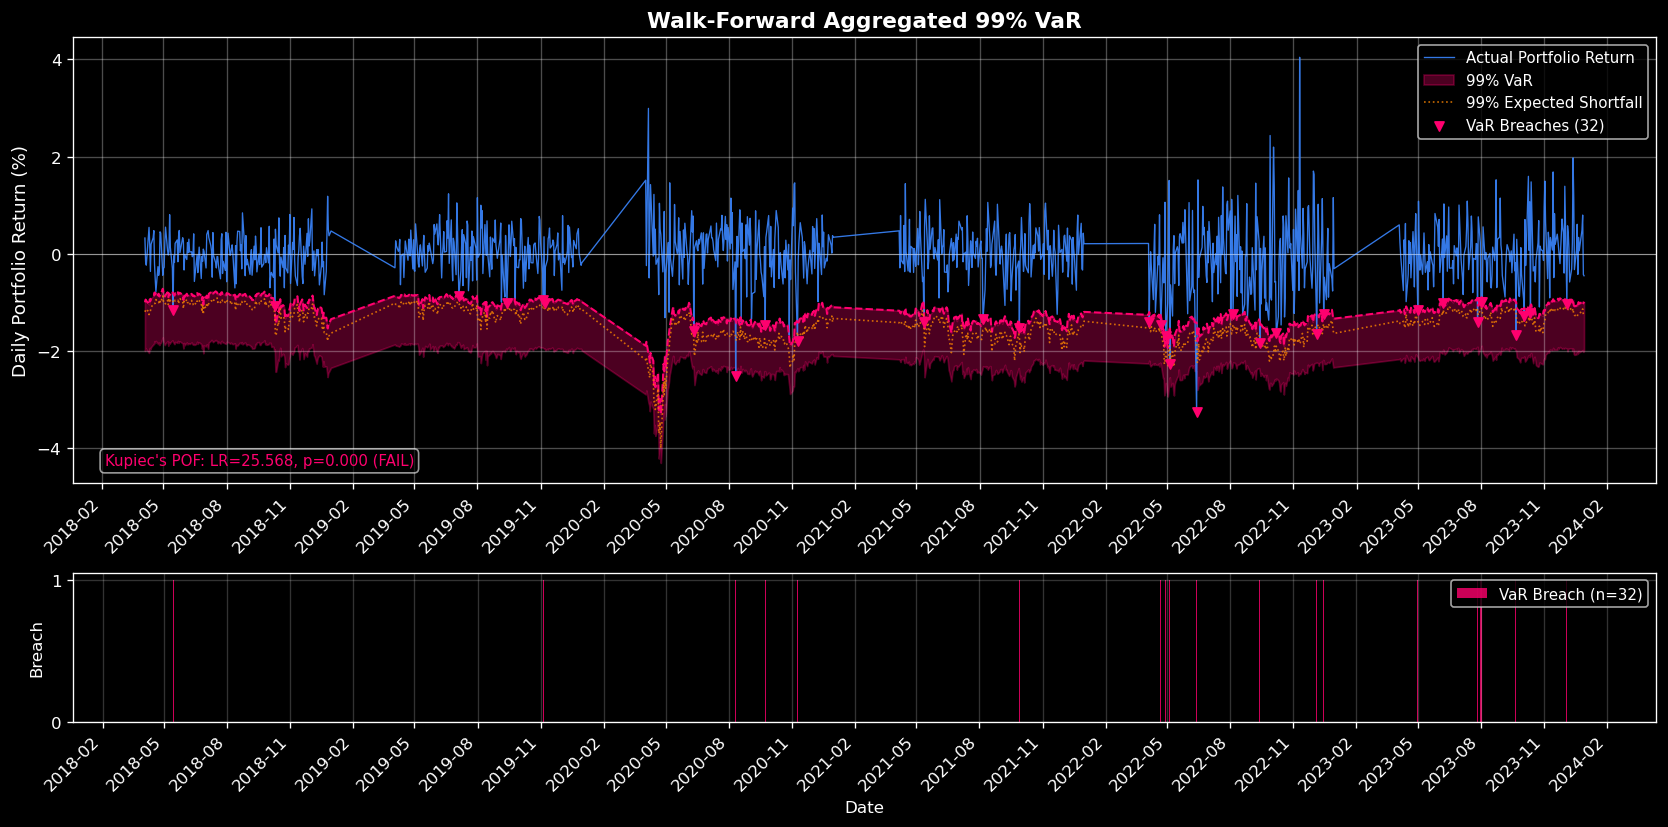

In [16]:
from src.data.pipeline import build_walk_forward_pipeline

# Re-assemble the master dataset from the 'info' dictionary created in previous cells
master_df = pd.concat([info["master_train"], info["master_val"], info["master_test"]])

# 1. Initialize Walk-Forward Generator 
pipeline_generator = build_walk_forward_pipeline(
    master=master_df,
    seq_len=63,
    batch_size=64,
    start_year=2005,
    initial_train_end_year=2016, 
    end_year=2023,
    val_years=1,
    test_years=1,
)

all_test_results = []
fold_model = None
trainer = None
fold = 1

print("Starting Walk-Forward Validation...")
total_start_time = time.time()

for train_loader, val_loader, test_loader, ret_scaler, fold_info in pipeline_generator:
    print("-" * 60)
    print(f"Fold {fold} | Train End: {fold_info['train_end']} | Test: {fold_info['test_start']} to {fold_info['test_end']}")
    
    if fold_model is None:
        # Construct identical model using pre-imported ConditionalNormalizingFlow
        fold_model = ConditionalNormalizingFlow(
            num_macro_features=fold_info["num_macro_features"],
            num_assets=fold_info["num_assets"],
            tft_d_model=64,
            tft_n_heads=4,
            tft_n_lstm_layers=2,
            flow_n_layers=6,
            flow_hidden_dim=64,
            flow_n_hidden=2,
            dropout=0.1,
        ).to(device)

        # Uses the pre-imported Trainer class
        trainer = Trainer(
            model=fold_model,
            train_loader=train_loader,
            val_loader=val_loader,
            lr=3e-4,
            weight_decay=1e-4,
            n_epochs=20, # Keep short for notebook demo
            patience=5,
            checkpoint_path=f"checkpoints/best_model_fold_{fold}.pt",
            device=device,
            warmup_epochs=2,
        )
    else:
        print("Warm-starting model...")
        trainer.checkpoint_path = f"checkpoints/best_model_fold_{fold}.pt"
        trainer.reset_for_new_fold(new_train_loader=train_loader, new_val_loader=val_loader, reset_lr=True)

    trainer.fit()
    trainer.load_best_model()

    # Uses the pre-imported Backtester class
    backtester = Backtester(
        model=fold_model,
        test_loader=test_loader,
        test_dates=fold_info["dates_test"],
        ret_scaler=ret_scaler,
        tickers=fold_info["tickers"],
        n_mc_samples=5000, 
        alpha=0.01,
        device=device,
    )
    
    chunk_results = backtester.run_chunk()
    all_test_results.append(chunk_results)
    
    fold += 1

elapsed = time.time() - total_start_time
print("-" * 60)
print(f"Walk-Forward Cross-Validation Complete in {elapsed/60:.2f} minutes.")

# Aggregate Results
df_results = pd.concat(all_test_results).sort_index()

n_total = len(df_results)
n_breaches = int(df_results["breach"].sum())
alpha = 0.01

print(f"Aggregated OOS Period: {df_results.index[0].date()} to {df_results.index[-1].date()}")
print(f"Total aggregate VaR breaches: {n_breaches} / {n_total} ({(n_breaches/n_total)*100:.2f}%)")

# Uses the pre-imported kupiec_pof_test
kupiec = kupiec_pof_test(n_breaches, n_total, alpha)
print(f"Global Kupiec LR Statistic: {kupiec.lr_statistic:.4f}, p-value: {kupiec.p_value:.4f}")

backtester.results = df_results
backtester.kupiec_result = kupiec
fig = backtester.plot_var_bands(title="Walk-Forward Aggregated 99% VaR")